In [1]:
import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def create_cols_name(data):
    number_of_bodies = int((data.shape[1]-1)/6)
    cols = ['T']
    for body_number in range(number_of_bodies):
        for letter in ['X{}', 'Y{}', 'Z{}']:
            cols.append(letter.format(body_number))

    for body_number in range(number_of_bodies):
        for letter in ['Vx{}', 'Vy{}', 'Vz{}']:
            cols.append(letter.format(body_number))
            
    return cols

In [3]:
files_path = os.getcwd() + '/../simulation_results/*.txt'
files = glob.glob(files_path)
files

['/home/mateus/Documents/TCC/src/../simulation_results/0-2019-11-28 22:01:39.036078.txt',
 '/home/mateus/Documents/TCC/src/../simulation_results/30-2019-11-28 22:01:39.100051.txt',
 '/home/mateus/Documents/TCC/src/../simulation_results/-90-2019-11-28 22:01:39.073520.txt',
 '/home/mateus/Documents/TCC/src/../simulation_results/60-2019-11-28 22:01:38.050208.txt',
 '/home/mateus/Documents/TCC/src/../simulation_results/-60-2019-11-28 22:01:38.126665.txt',
 '/home/mateus/Documents/TCC/src/../simulation_results/-30-2019-11-28 22:01:34.278614.txt',
 '/home/mateus/Documents/TCC/src/../simulation_results/90-2019-11-28 22:01:38.527321.txt']

<IPython.core.display.Javascript object>


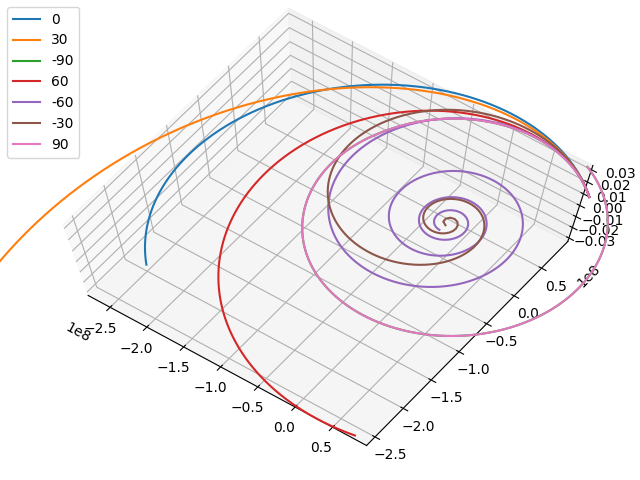

In [4]:
%matplotlib notebook

files_path = os.getcwd() + '/../simulation_results/*.txt'
files = glob.glob(files_path)

fig = plt.figure()
ax = Axes3D(fig)

# regex to get the first number after the string "simulation_results"
regex = r'(simulation_results)(\D)([-+]?\d+)'
for path in files:
    matches = re.search(regex, path, re.IGNORECASE)
    df = pd.read_csv(path, header=None)
    df.columns = create_cols_name(df)
    ax.plot(df['X6'], df['Y6'], df['Z6'], label=matches.groups()[2])

# ax.plot(df1['X1'], df1['Y1'], df1['Z1'], label='earth')
# ax.plot(df1['X2'], df1['Y2'], df1['Z2'], label='moon')

ax.legend()

<IPython.core.display.Javascript object>


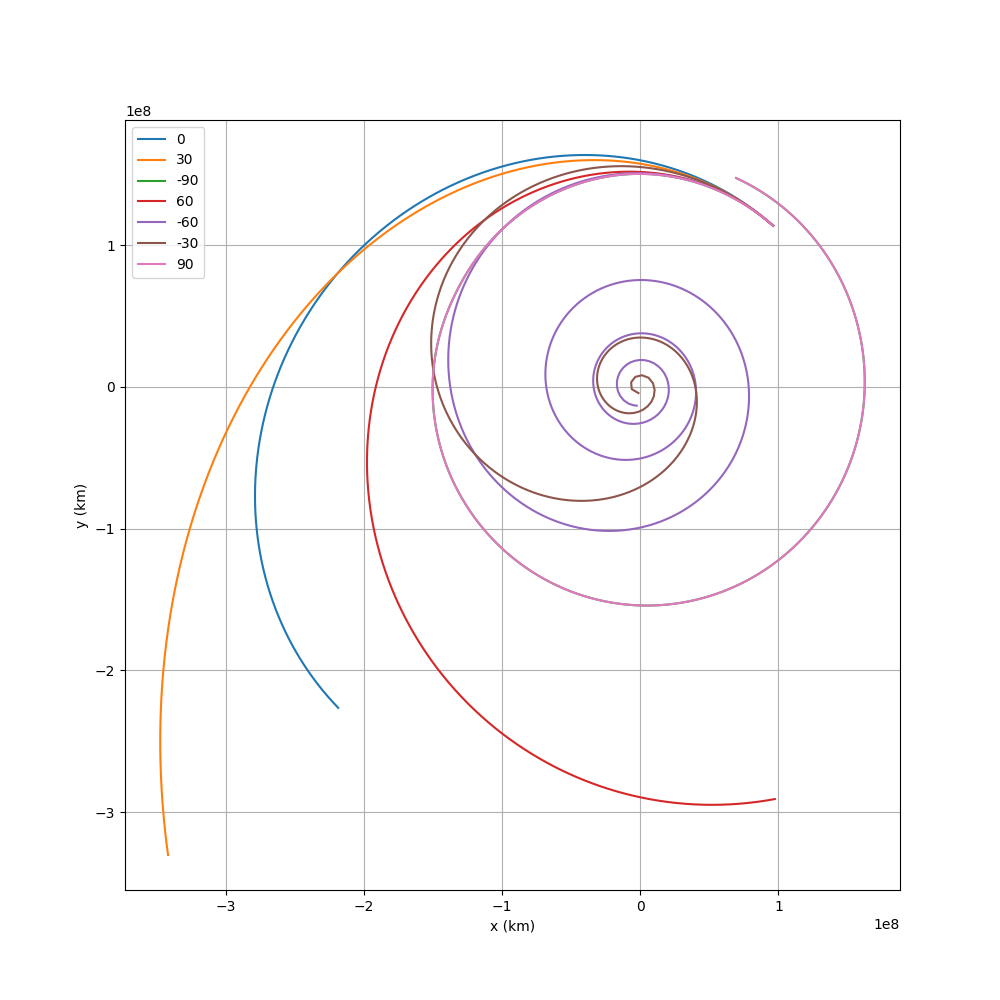

Text(0, 0.5, 'y (km)')

In [5]:
%matplotlib notebook



files_path = os.getcwd() + '/../simulation_results/*.txt'
files = glob.glob(files_path)

fig, ax = plt.subplots(figsize=(10,10))

for path in files:
    matches = re.search(regex, path, re.IGNORECASE)
    df = pd.read_csv(path, header=None)
    df.columns = create_cols_name(df)
    ax.plot(df['X6'], df['Y6'], label=matches.groups()[2])


ax.axis(fontsize=10)
ax.legend(loc='upper left', fontsize=10)
ax.tick_params(labelsize=10)
ax.yaxis.offsetText.set_fontsize(10)
ax.xaxis.offsetText.set_fontsize(10)
ax.grid(True)
ax.set_xlabel('x (km)', fontsize=10)
ax.set_ylabel('y (km)', fontsize=10)

In [ ]:
vela_0 = r'/home/mateus/Documents/TCC/simulation_results/demonstration/0-2019-11-28 21:44:37.766857.txt'
vela_30 = r'/home/mateus/Documents/TCC/simulation_results/demonstration/30-2019-11-28 21:43:58.867811.txt'

fig, ax = plt.subplots(figsize=(10,10))

df0 = pd.read_csv(vela_0, header=None)
df0.columns = create_cols_name(df0)
df30 = pd.read_csv(vela_30, header=None)
df30.columns = create_cols_name(df30)

ax.plot(df0['X1'], df0['Y1'], label='Venus', color='brown')
ax.plot(df0['X2'], df0['Y2'], label='Terra', color='blue')
ax.plot(df0['X4'], df0['Y4'], label='Terra', color='red')
ax.plot(df0['X6'], df0['Y6'], label='0')
ax.plot(df30['X6'], df30['Y6'], label='0')
ax.axis('equal')

ax.axis(fontsize=10)
ax.legend(loc='upper left', fontsize=10)
ax.tick_params(labelsize=10)
ax.yaxis.offsetText.set_fontsize(10)
ax.xaxis.offsetText.set_fontsize(10)
ax.grid(True)
ax.set_xlabel('x (km)', fontsize=10)
ax.set_ylabel('y (km)', fontsize=10)